# 04 — Rack Reconfiguration

**Question:** Can Chamber A be re-racked to fit the client's stock — and what does it do to the cost of storing each pallet?

Where Notebooks 1–3 left us, Chamber A needs:

| Requirement | Amount | Available today |
|---|---|---|
| Pallet positions | 2,102 | 1,900 |
| Shelving bins | 580 | 0 |

Every opening in Chamber A is 175 cm high — built for the tallest pallet. But Notebook 1 showed pallet heights vary widely. A 70 cm pallet in a 175 cm opening leaves more than a metre of air above it. This notebook recovers that air by matching beam heights to the pallets that actually need storing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA, OUT = Path("../data"), Path("../outputs")
stock = pd.read_csv(DATA / "storage_requirement.csv")
slotting = pd.read_csv(DATA / "slotting.csv")

# Chamber A physical constants
BAYS = 190                # rack bays
POS_PER_LEVEL = 2         # pallets side by side on each beam level
USABLE_HEIGHT = 950       # cm, floor to highest allowable top of load (below sprinklers)
BEAM = 12                 # cm, beam depth
LIFT_CLEARANCE = 10       # cm, gap a forklift needs above a pallet
PALLET_DECK = 15          # cm

## 1. One row per pallet position — including partial pallets

A batch of 3.4 pallets occupies four positions: three full pallets and one part pallet. The part pallet has fewer layers, so it's **shorter** — and shorter pallets fit in lower openings. Treating every position as a full-height pallet would understate what reconfiguration can achieve.

In [2]:
rack = stock[(stock.storage_condition == "Below 25C") & (stock.zone == "Pallet racking")]

heights = []
for r in rack.itertuples():
    full = int(np.floor(r.pallets))
    heights += [r.pallet_height_cm] * full
    part = r.pallets - full
    if part > 1e-9:
        layers = int(np.ceil(part * r.cases_per_pallet / r.ti - 1e-9))
        heights.append(PALLET_DECK + layers * r.case_height_cm)

pos = pd.DataFrame({"pallet_height_cm": heights})
print(f"{len(pos):,} pallet positions to store")
pos.pallet_height_cm.describe().round(1)

2,102 pallet positions to store


count    2102.0
mean       98.5
std        30.5
min        30.2
25%        75.0
50%        98.0
75%       121.5
max       163.4
Name: pallet_height_cm, dtype: float64

## 2. Height classes

Three standard opening heights. A pallet fits an opening if it's at least 10 cm shorter, leaving room for the forklift to lift it clear.

| Class | Opening | Takes pallets up to |
|---|---|---|
| Low | 95 cm | 85 cm |
| Medium | 130 cm | 120 cm |
| High | 175 cm | 165 cm |

In [3]:
OPENINGS = {"Low": 95, "Medium": 130, "High": 175}

pos["height_class"] = pd.cut(pos.pallet_height_cm,
                             [0, OPENINGS["Low"] - LIFT_CLEARANCE, OPENINGS["Medium"] - LIFT_CLEARANCE, 999],
                             labels=["Low", "Medium", "High"])
demand = pos.height_class.value_counts().reindex(["Low", "Medium", "High"])
demand.to_frame("positions needed")

,positions needed
height_class,
Low,789
Medium,744
High,569


## 3. How much air is Chamber A storing today?

**Vertical fill** = pallet height ÷ opening height. A 98 cm pallet in a 175 cm opening is 56% full.

In [4]:
fill_today = (pos.pallet_height_cm / OPENINGS["High"]).mean()
print(f"Average vertical fill today: {fill_today:.0%}")
print(f"Pallets that would fit a Low or Medium opening: {(pos.height_class != 'High').mean():.0%}")

Average vertical fill today: 56%
Pallets that would fit a Low or Medium opening: 73%


## 4. Bay types

Beam heights can be changed bay by bay. Each bay type must fit within the 950 cm usable height, with a beam under every level except the ground.

| Bay type | Levels | Positions |
|---|---|---|
| **High** (current) | 5 × 175 cm | 10 High |
| **Medium** | 6 × 130 cm + 1 × 95 cm | 12 Medium + 2 Low |
| **Low** | 8 × 95 cm | 16 Low |
| **Shelving** | 240 cm hand-pick shelving + 5 × 130 cm pallet levels above | 24 bins + 10 Medium |

In [5]:
def bay_height(openings):
    return sum(openings) + BEAM * (len(openings) - 1)

BAY_TYPES = {
    "High":     [175] * 5,
    "Medium":   [130] * 6 + [95],
    "Low":      [95] * 8,
    "Shelving": [240] + [130] * 5,   # first 'opening' is the shelving unit
}
for name, levels in BAY_TYPES.items():
    h = bay_height(levels)
    print(f"{name:9} {h:>4} cm  {'fits' if h <= USABLE_HEIGHT else 'TOO TALL'}")

# Positions each bay type provides, by class (x2 pallets per level)
YIELD = {
    "High":     {"Low": 0,  "Medium": 0,  "High": 10},
    "Medium":   {"Low": 2,  "Medium": 12, "High": 0},
    "Low":      {"Low": 16, "Medium": 0,  "High": 0},
    "Shelving": {"Low": 0,  "Medium": 10, "High": 0},
}
BINS_PER_SHELVING_BAY = 24     # 6 shelves x 4 bins

High       923 cm  fits
Medium     947 cm  fits
Low        844 cm  fits
Shelving   950 cm  fits


## 5. Shelving bays needed

580 bins from Notebooks 2 and 3: 448 for small batches and 132 as pick bins for B-class SKUs.

In [6]:
bins_needed = (stock[(stock.storage_condition == "Below 25C") & (stock.zone == "Shelving")].shape[0]
               + slotting[slotting.storage_condition == "Below 25C"].pick_bins.sum())
n_shelving = int(np.ceil(bins_needed / BINS_PER_SHELVING_BAY))
print(f"{bins_needed} bins needed -> {n_shelving} shelving bays ({n_shelving * BINS_PER_SHELVING_BAY} bins)")

580 bins needed -> 25 shelving bays (600 bins)


## 6. Test every combination

With 190 bays and the shelving bays fixed, there are only a few thousand ways to split the rest between High, Medium and Low — few enough to test every one.

A combination is **feasible** if it stores every pallet with a **10% buffer** for growth. Because a short pallet can always go in a taller opening, the check is cumulative:

- High positions ≥ High pallets
- High + Medium positions ≥ High + Medium pallets
- All positions ≥ all pallets

Among feasible options, choose the one that **changes the fewest bays** — every reconfigured bay costs money and disrupts operations. Ties go to the option with the most positions.

In [7]:
BUFFER = 1.10
need_H = demand["High"] * BUFFER
need_HM = (demand["High"] + demand["Medium"]) * BUFFER
need_all = demand.sum() * BUFFER

options = []
for n_high in range(BAYS - n_shelving + 1):
    for n_med in range(BAYS - n_shelving - n_high + 1):
        n_low = BAYS - n_shelving - n_high - n_med
        counts = {"High": n_high, "Medium": n_med, "Low": n_low, "Shelving": n_shelving}
        cap = {c: sum(counts[b] * YIELD[b][c] for b in counts) for c in ["Low", "Medium", "High"]}
        if cap["High"] >= need_H and cap["High"] + cap["Medium"] >= need_HM and sum(cap.values()) >= need_all:
            options.append({**{f"{k}_bays": v for k, v in counts.items()},
                            "bays_changed": BAYS - n_high,
                            **{f"{c}_positions": v for c, v in cap.items()},
                            "total_positions": sum(cap.values())})

options = pd.DataFrame(options).sort_values(["bays_changed", "total_positions"], ascending=[True, False])
print(f"{len(options):,} feasible combinations")
options.head(5)

660 feasible combinations


,High_bays,Medium_bays,Low_bays,Shelving_bays,bays_changed,Low_positions,Medium_positions,High_positions,total_positions
657,86,28,51,25,104,872,586,860,2318
658,86,29,50,25,104,858,598,860,2316
659,86,30,49,25,104,844,610,860,2314
652,85,29,51,25,105,874,598,850,2322
653,85,30,50,25,105,860,610,850,2320


In [8]:
best = options.iloc[0]
compare = pd.DataFrame({
    "Today": {"High bays": BAYS, "Medium bays": 0, "Low bays": 0, "Shelving bays": 0,
              "Pallet positions": BAYS * 10, "Shelving bins": 0},
    "Reconfigured": {"High bays": best.High_bays, "Medium bays": best.Medium_bays, "Low bays": best.Low_bays,
                     "Shelving bays": best.Shelving_bays, "Pallet positions": best.total_positions,
                     "Shelving bins": best.Shelving_bays * BINS_PER_SHELVING_BAY},
})
compare["Change"] = compare.Reconfigured - compare.Today
compare

,Today,Reconfigured,Change
High bays,190,86,-104
Medium bays,0,28,28
Low bays,0,51,51
Shelving bays,0,25,25
Pallet positions,1900,2318,418
Shelving bins,0,600,600


## 7. Vertical fill after reconfiguration

Each pallet goes into the smallest opening it fits. Where a class is full, the pallet moves up to the next class.

In [9]:
remaining = {c: int(best[f"{c}_positions"]) for c in ["Low", "Medium", "High"]}
order = ["Low", "Medium", "High"]
assigned = []
# Tallest pallets first, so High pallets are guaranteed a High opening
for h, c in pos.sort_values("pallet_height_cm", ascending=False)[["pallet_height_cm", "height_class"]].itertuples(index=False):
    for opening in order[order.index(c):]:
        if remaining[opening] > 0:
            remaining[opening] -= 1
            assigned.append((h, opening))
            break

placed = pd.DataFrame(assigned, columns=["pallet_height_cm", "opening"])
fill_after = (placed.pallet_height_cm / placed.opening.map(OPENINGS)).mean()

print(f"Vertical fill today: {fill_today:.0%}")
print(f"Vertical fill after: {fill_after:.0%}")
placed.opening.value_counts().reindex(order).to_frame("pallets placed")

Vertical fill today: 56%
Vertical fill after: 74%


,pallets placed
opening,
Low,789
Medium,586
High,727


## 8. Cost

**Assumptions** (illustrative):

| Item | Value |
|---|---|
| Chamber A operating cost (rent, temperature control, overheads) | NZ$620,000 a year |
| New beam pair, supplied and installed | NZ$220 |
| Hand-pick shelving unit, installed | NZ$3,000 |
| Reconfiguration written off over | 10 years |
| External overflow storage, incl. shuttle transport | NZ$1.20 per pallet per day |

**Cost per pallet per day** = annual chamber cost ÷ (capacity × 365). Shelving is counted at **2 bins = 1 pallet equivalent**.

In [10]:
ANNUAL_COST = 620_000
BEAM_PAIR, SHELF_UNIT = 220, 3_000
LIFE_YEARS = 10
OVERFLOW_RATE = 1.20

beams_per_bay = {k: len(v) - 1 for k, v in BAY_TYPES.items()}
beams_after = sum(best[f"{k}_bays"] * beams_per_bay[k] for k in BAY_TYPES)
new_beams = beams_after - BAYS * beams_per_bay["High"]
capex = new_beams * BEAM_PAIR + best.Shelving_bays * SHELF_UNIT

eq_today = BAYS * 10
eq_after = best.total_positions + best.Shelving_bays * BINS_PER_SHELVING_BAY / 2
cpd_today = ANNUAL_COST / (eq_today * 365)
cpd_after = (ANNUAL_COST + capex / LIFE_YEARS) / (eq_after * 365)

shortfall_today = 650   # Notebook 2: positions short with no reconfiguration
overflow_cost = shortfall_today * OVERFLOW_RATE * 365

cost = pd.Series({
    "New beam pairs": new_beams,
    "Reconfiguration cost (NZ$)": capex,
    "Capacity today (pallet equivalents)": eq_today,
    "Capacity after (pallet equivalents)": eq_after,
    "Capacity increase": eq_after / eq_today - 1,
    "Cost per pallet per day today (NZ$)": cpd_today,
    "Cost per pallet per day after (NZ$)": cpd_after,
    "Reduction": 1 - cpd_after / cpd_today,
    "Overflow cost avoided per year (NZ$)": overflow_cost,
    "Payback (months)": capex / overflow_cost * 12,
})
cost.to_frame("value").style.format("{:,.2f}")

,value
New beam pairs,234.00
Reconfiguration cost (NZ$),"126,480.00"
Capacity today (pallet equivalents),"1,900.00"
Capacity after (pallet equivalents),"2,618.00"
Capacity increase,0.38
Cost per pallet per day today (NZ$),0.89
Cost per pallet per day after (NZ$),0.66
Reduction,0.26
Overflow cost avoided per year (NZ$),"284,700.00"
Payback (months),5.33


## 9. Before and after

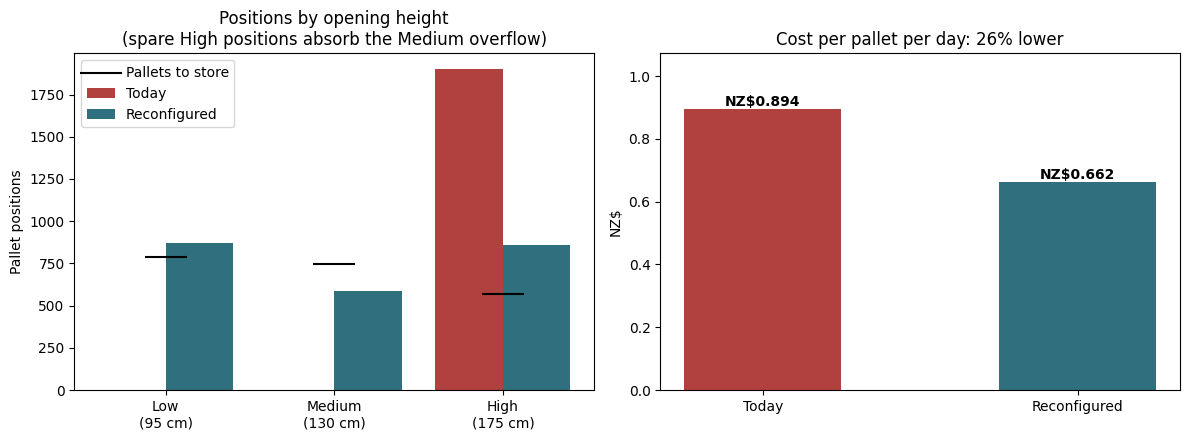

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: positions by class, today vs after, against need
classes = ["Low", "Medium", "High"]
today = [0, 0, BAYS * 10]
after = [best[f"{c}_positions"] for c in classes]
x = np.arange(len(classes))
axes[0].bar(x - 0.2, today, 0.4, label="Today", color="#b0413e")
axes[0].bar(x + 0.2, after, 0.4, label="Reconfigured", color="#2f6f7e")
axes[0].scatter(x, demand.values, color="black", zorder=3, label="Pallets to store", marker="_", s=900)
axes[0].set_xticks(x, [f"{c}\n({OPENINGS[c]} cm)" for c in classes])
axes[0].set(title="Positions by opening height\n(spare High positions absorb the Medium overflow)", ylabel="Pallet positions")
axes[0].legend()

# Right: cost per pallet per day
bars = axes[1].bar(["Today", "Reconfigured"], [cpd_today, cpd_after], color=["#b0413e", "#2f6f7e"], width=0.5)
for b in bars:
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01, f"NZ${b.get_height():.3f}", ha="center", fontweight="bold")
axes[1].set(title=f"Cost per pallet per day: {1 - cpd_after / cpd_today:.0%} lower", ylabel="NZ$", ylim=(0, cpd_today * 1.2))

plt.tight_layout()
plt.savefig(OUT / "04_reconfiguration.png", dpi=150)
plt.show()

## 10. Save

In [12]:
with pd.ExcelWriter(OUT / "04_rack_reconfiguration.xlsx") as xl:
    demand.to_frame("positions needed").to_excel(xl, sheet_name="Demand by height class")
    options.head(20).to_excel(xl, sheet_name="Top options", index=False)
    compare.to_excel(xl, sheet_name="Before vs after")
    cost.to_frame("value").to_excel(xl, sheet_name="Cost")
print("Saved 04_rack_reconfiguration.xlsx")

Saved 04_rack_reconfiguration.xlsx


## Findings

- **Chamber A is storing a lot of air.** 73% of the pallets would fit a lower opening than 175 cm, and average vertical fill is just 56%.
- **660 bay combinations can store all the stock with a 10% growth buffer.** The chosen option changes the fewest bays: **104 of 190**, keeping 86 as they are.
- **Pallet positions rise from 1,900 to 2,318 (+22%), and 600 shelving bins are created where there were none.** That covers the 2,102 positions and 580 bins required.
- **Vertical fill improves from 56% to 74%.**
- **The reconfiguration costs about NZ$126,000** — 234 new beam pairs and 25 shelving units — and increases capacity by 38% in pallet equivalents.
- **Cost per pallet per day falls from NZ$0.894 to NZ$0.662, a 26% reduction**, after including the reconfiguration cost.
- **It pays back in about five months** compared with overflowing 650 pallets to external storage at NZ$285,000 a year.

**Trade-off worth noting:** keeping 86 High bays unchanged leaves more High positions than strictly needed. Options that change more bays add more positions — the *Top options* sheet shows the trade-off between disruption and capacity. All costs are illustrative assumptions.